# Proyecto Módulo 6 – Predicción inteligente de gasto en clientes e-commerce

Dataset: `amazon_sales_dataset.csv` (10.000 pedidos de un e-commerce con información de clientes, productos y ventas).

## 0. Configuración inicial

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics


sns.set(style='whitegrid')

### 0.1 Carga del dataset y preparación básica

In [2]:
df = pd.read_csv('amazon_sales_dataset.csv')

# Convertir columnas de fecha a datetime
date_cols = ['order_date', 'ship_date', 'delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Crear features de demora de envío y entrega
df['shipping_delay_days'] = (df['ship_date'] - df['order_date']).dt.days
df['delivery_delay_days'] = (df['delivery_date'] - df['ship_date']).dt.days

df.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method,shipping_delay_days,delivery_delay_days
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card,0,-23
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD,14,0
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI,23,-35
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card,-3,5
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI,-23,19


## 1. Definición del problema y EDA breve (Lección 1)

**Objetivo de negocio:** predecir el monto de venta (`total_sales`) de cada pedido a partir del perfil del cliente, características del producto y comportamiento logístico.

Es un problema de **regresión supervisada** porque la variable objetivo es continua (monto en dinero).

In [3]:
# Dimensiones y tipos
df.shape, df.dtypes

((10000, 23),
 order_id                       object
 order_date             datetime64[ns]
 ship_date              datetime64[ns]
 delivery_date          datetime64[ns]
 order_status                   object
 customer_id                    object
 customer_name                  object
 country                        object
 state                          object
 city                           object
 product_id                     object
 product_name                   object
 category                       object
 sub_category                   object
 brand                          object
 quantity                        int64
 unit_price                    float64
 discount                      float64
 shipping_cost                 float64
 total_sales                   float64
 payment_method                 object
 shipping_delay_days             int64
 delivery_delay_days             int64
 dtype: object)

In [4]:
# Estadísticos descriptivos de variables numéricas
df[['quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales',
    'shipping_delay_days', 'delivery_delay_days']].describe()

,quantity,unit_price,discount,shipping_cost,total_sales,shipping_delay_days,delivery_delay_days
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.01440,25126.511133,0.149968,85.053192,64212.910555,-0.057700,0.101900
std,1.42035,14343.922332,0.086828,37.575284,50992.635082,16.658413,16.839468
min,1.00000,214.200000,0.000000,20.010000,309.939600,-40.000000,-40.000000
25%,2.00000,12657.827500,0.070000,52.507500,24037.196775,-12.000000,-12.000000
50%,3.00000,24880.490000,0.150000,84.995000,50287.177500,0.000000,0.000000
75%,4.00000,37544.640000,0.220000,117.680000,93417.891825,12.000000,12.000000
max,5.00000,49981.880000,0.300000,149.950000,249155.530000,40.000000,40.000000


### 1.1 Definir variable objetivo y características

In [5]:
target_col = 'total_sales'
feature_cols = [c for c in df.columns if c != target_col]

y = df[target_col]
X = df[feature_cols]

print('Target:', target_col)
print('N features:', len(feature_cols))

Target: total_sales
N features: 22


## 2. Nivel de ajuste del modelo y validación cruzada (Lección 2)

ojo tiempo de ejecucion 20 min aprox 

In [6]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo base muy simple: regresión lineal directa (sin preprocesamiento complejo)
modelo_base = LinearRegression()
modelo_base.fit(pd.get_dummies(X_train.select_dtypes(exclude='datetime64[ns]'), drop_first=True), y_train)

X_train_enc = pd.get_dummies(X_train.select_dtypes(exclude='datetime64[ns]'), drop_first=True)
X_test_enc = pd.get_dummies(X_test.select_dtypes(exclude='datetime64[ns]'), drop_first=True)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

y_train_pred = modelo_base.predict(X_train_enc)
y_test_pred = modelo_base.predict(X_test_enc)

def print_regression_metrics(y_true, y_pred, nombre='Modelo'):
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_true, y_pred)
    print("--- {} ---".format(nombre))
    print("MAE : {:.2f}".format(mae))
    print("RMSE: {:.2f}".format(rmse))
    print("R2  : {:.4f}".format(r2))

print_regression_metrics(y_train, y_train_pred, 'Base - Train')
print_regression_metrics(y_test, y_test_pred, 'Base - Test')

# Validación cruzada K-Fold sobre todo el dataset codificado
X_full_enc = pd.get_dummies(X.select_dtypes(exclude='datetime64[ns]'), drop_first=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelo_base, X_full_enc, y, cv=kf,
                            scoring='neg_mean_absolute_error')
print('CV MAE medio:', -cv_scores.mean())

--- Base - Train ---
MAE : 0.00
RMSE: 0.00
R2  : 1.0000
--- Base - Test ---
MAE : 15231.50
RMSE: 19930.54
R2  : 0.8480
CV MAE medio: 15207.898222991469


## 3. Preprocesamiento y escalamiento de datos (Lección 3)

In [7]:
# Definir columnas numéricas y categóricas
numeric_features = ['quantity', 'unit_price', 'discount',
                    'shipping_cost', 'shipping_delay_days',
                    'delivery_delay_days']

categorical_features = ['country', 'state', 'city',
                        'category', 'sub_category',
                        'brand', 'payment_method']

from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 4. Regresiones: lineal y polinomial (Lección 4)

In [8]:
# Pipeline con regresión lineal
linear_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
y_pred_lin = linear_pipeline.predict(X_test)
print_regression_metrics(y_test, y_pred_lin, 'Regresión lineal (pipeline)')

# Pipeline con características polinomiales sobre las numéricas
poly_numeric = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', poly_numeric, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

poly_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor_poly),
    ('model', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)
print_regression_metrics(y_test, y_pred_poly, 'Regresión polinomial (grado 2)')

--- Regresión lineal (pipeline) ---
MAE : 15002.68
RMSE: 20044.87
R2  : 0.8462
--- Regresión polinomial (grado 2) ---
MAE : 1367.50
RMSE: 1983.93
R2  : 0.9985


## 5. Algoritmos de clasificación (Lección 5, enfoque conceptual)

En este proyecto el objetivo central es regresivo.
De forma opcional se puede transformar `total_sales` en una etiqueta binaria (alto/bajo gasto) y entrenar un KNN clasificador para comparar enfoques.

In [9]:
# Ejemplo opcional: crear una etiqueta binaria de alto gasto
threshold = y_train.median()
y_bin_train = (y_train >= threshold).astype(int)
y_bin_test = (y_test >= threshold).astype(int)

knn_clf = KNeighborsRegressor(n_neighbors=5)
knn_clf.fit(preprocessor.fit_transform(X_train), y_train)

y_pred_knn = knn_clf.predict(preprocessor.transform(X_test))
print_regression_metrics(y_test, y_pred_knn, 'KNN Regressor')




--- KNN Regressor ---
MAE : 12731.36
RMSE: 16851.44
R2  : 0.8913


## 6. Métricas de desempeño (Lección 6)

In [10]:
def compute_metrics(y_true, y_pred):
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

resultados = []

for nombre, preds in [
    ('Regresión lineal', y_pred_lin),
    ('Regresión polinomial', y_pred_poly)
]:
    mae, mse, rmse, r2 = compute_metrics(y_test, preds)
    resultados.append({
        'modelo': nombre,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,modelo,MAE,MSE,RMSE,R2
0,Regresión lineal,15002.678036,4.017967e+08,20044.866785,0.846245
1,Regresión polinomial,1367.502223,3.935981e+06,1983.930586,0.998494


## 7. Optimización del modelo (Lección 7) – Ridge

In [11]:
ridge_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0]
}

grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)
print('Mejores parámetros Ridge:', grid_ridge.best_params_)

y_pred_ridge = grid_ridge.predict(X_test)
print_regression_metrics(y_test, y_pred_ridge, 'Ridge optimizado')

mae, mse, rmse, r2 = compute_metrics(y_test, y_pred_ridge)
resultados.append({'modelo': 'Ridge optimizado', 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
resultados_df = pd.DataFrame(resultados)
resultados_df

Mejores parámetros Ridge: {'model__alpha': 10.0}
--- Ridge optimizado ---
MAE : 13739.05
RMSE: 18467.92
R2  : 0.8695


,modelo,MAE,MSE,RMSE,R2
0,Regresión lineal,15002.678036,4.017967e+08,20044.866785,0.846245
1,Regresión polinomial,1367.502223,3.935981e+06,1983.930586,0.998494
2,Ridge optimizado,13739.047226,3.410640e+08,18467.917224,0.869486


## 8. Algoritmos de Boosting (Lección 8) – GradientBoostingRegressor

In [12]:
gbr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid_gbr = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.1, 0.05, 0.01],
    'model__max_depth': [3, 4]
}

grid_gbr = GridSearchCV(
    gbr_pipeline,
    param_grid_gbr,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_gbr.fit(X_train, y_train)
print('Mejores parámetros Gradient Boosting:', grid_gbr.best_params_)

y_pred_gbr = grid_gbr.predict(X_test)
print_regression_metrics(y_test, y_pred_gbr, 'Gradient Boosting optimizado')

mae, mse, rmse, r2 = compute_metrics(y_test, y_pred_gbr)
resultados.append({'modelo': 'Gradient Boosting optimizado', 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
resultados_df = pd.DataFrame(resultados)
resultados_df.sort_values('RMSE')

Mejores parámetros Gradient Boosting: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}
--- Gradient Boosting optimizado ---
MAE : 952.24
RMSE: 1235.89
R2  : 0.9994


,modelo,MAE,MSE,RMSE,R2
3,Gradient Boosting optimizado,952.238585,1.527433e+06,1235.893506,0.999415
1,Regresión polinomial,1367.502223,3.935981e+06,1983.930586,0.998494
2,Ridge optimizado,13739.047226,3.410640e+08,18467.917224,0.869486
0,Regresión lineal,15002.678036,4.017967e+08,20044.866785,0.846245


## 9. Visualizaciones finales

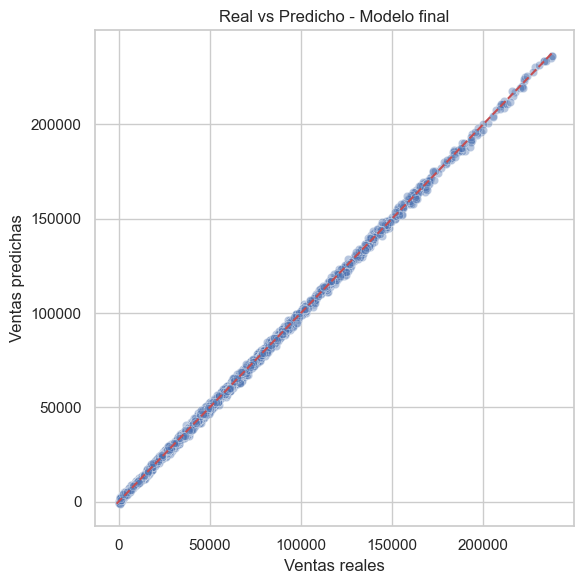

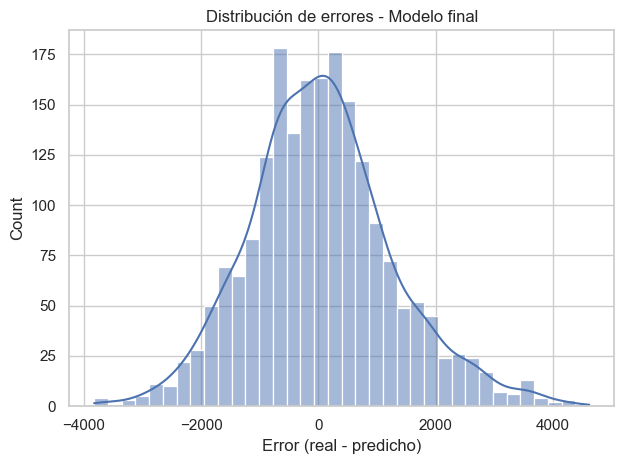

In [ ]:
# Suponemos que el modelo final es Gradient Boosting optimizado
y_pred_final = y_pred_gbr

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.4)
plt.xlabel('Ventas reales')
plt.ylabel('Ventas predichas')
plt.title('Real vs Predicho - Modelo final')
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.tight_layout()
plt.show()

# Distribución de errores
errores = y_test - y_pred_final
sns.histplot(errores, kde=True) #                                                                                                                      LO HIZO YURI URZUA 
plt.title('Distribución de errores - Modelo final')
plt.xlabel('Error (real - predicho)')
plt.tight_layout()
plt.show()